# 1.4. UMAP i t-SNE: similarity scores liczone ręcznie — wersja dopracowana

Materiał jest **inspirowany stylem wyjaśniania StatQuest**, ale wszystkie rysunki, macierze i obliczenia w notebooku są przygotowane od zera w Pythonie.

Cel tego notebooka jest bardzo wąski:

> Pokazać, jak z odległości między punktami powstają **similarity scores**.

Na tym etapie **nie optymalizujemy jeszcze pełnej mapy 2D**. Chcemy najpierw zrozumieć, co UMAP i t-SNE uznają za „podobieństwo”.


## W tym notebooku użyjemy

✓ Macierzy odległości D

✓ Grafu kNN

✓ Ważonej macierzy sąsiedztwa A

## Obiekty matematyczne

Wejście:

✓ Punkty danych X

Budujemy:

✓ Macierz odległości D
✓ Graf kNN
✓ Ważoną macierz sąsiedztwa A

Wynik:

✓ Nowe współrzędne 2D

## Do jakiej rodziny należy metoda?

PCA:
→ metody projekcyjne

t-SNE:
→ metody podobieństw

UMAP:
→ metody grafowe

KNN:
→ metody sąsiedztwa

DBSCAN:
→ metody gęstościowe

KMeans:
→ metody centroidowe

LDA:
→ metody dyskryminacyjne

SVM:
→ metody maksymalnego marginesu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.set_printoptions(precision=3, suppress=True)

labels = list("ABCDEF")
colors = {
    "A": "tab:blue", "B": "tab:red", "C": "tab:pink",
    "D": "gold", "E": "khaki", "F": "lemonchiffon"
}

# Ręcznie ustawiona macierz odległości inspirowana przykładem A,B,C oraz osobną grupą D,E,F.
# Ważne: A,B,C są jedną lokalną grupą, D,E,F drugą lokalną grupą.
D = np.array([
    [0.0, 0.5, 2.4, 10.0,  9.5,  9.8],
    [0.5, 0.0, 2.0,  9.8,  9.0,  9.2],
    [2.4, 2.0, 0.0,  8.0,  8.2,  8.0],
    [10.0,9.8, 8.0,  0.0,  0.5,  0.3],
    [9.5, 9.0, 8.2,  0.5,  0.0,  0.4],
    [9.8, 9.2, 8.0,  0.3,  0.4,  0.0],
])

coords = {
    "A": (0.0, 1.3),
    "B": (0.0, 0.8),
    "C": (2.2, 0.25),
    "D": (7.2, 0.85),
    "E": (7.8, 0.85),
    "F": (7.5, 0.45),
}
X_plot = np.array([coords[l] for l in labels])

def df_matrix(M, fmt=True):
    df = pd.DataFrame(M, index=labels, columns=labels)
    return df.round(3) if fmt else df

def plot_points(ax=None, title="Punkty wejściowe", annotate_distances=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 3.6))
    for i, lab in enumerate(labels):
        ax.scatter(X_plot[i,0], X_plot[i,1], s=260, color=colors[lab], edgecolor='black', zorder=3)
        ax.text(X_plot[i,0], X_plot[i,1]+0.18, lab, ha='center', va='bottom', fontsize=14, fontweight='bold')
    if annotate_distances:
        pairs = [("A","B",0.5),("B","C",2.0),("A","C",2.4),("D","E",0.5),("D","F",0.3),("E","F",0.4)]
        for a,b,val in pairs:
            ia, ib = labels.index(a), labels.index(b)
            xa, ya = X_plot[ia]
            xb, yb = X_plot[ib]
            ax.plot([xa,xb],[ya,yb], color='0.75', linestyle='--', zorder=1)
            ax.text((xa+xb)/2, (ya+yb)/2+0.08, f"{val}", ha='center', fontsize=10, color='0.35')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-0.8, 8.6)
    ax.set_ylim(-0.2, 1.8)
    ax.axis('off')
    return ax

def plot_heatmap(M, title, ax=None, vmin=0, vmax=1, cmap='Reds', annotate=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_title(title)
    if annotate:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i,j]
                txt = "" if np.isnan(val) else f"{val:.2f}"
                ax.text(j, i, txt, ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

def directed_knn_indices(D, n_neighbors=2):
    neigh = []
    for i in range(D.shape[0]):
        order = np.argsort(D[i])
        order = [j for j in order if j != i]
        neigh.append(order[:n_neighbors])
    return neigh

def solve_sigma_for_two_neighbors(distances, target=np.log2(3)):
    # Zakładamy local_connectivity=1: najbliższy sąsiad po przesunięciu rho ma wagę 1.
    # Dla drugiego sąsiada dobieramy sigma tak, aby 1 + exp(-(d2-rho)/sigma) = target.
    rho = min(distances)
    other = max(distances)
    desired_other = target - 1.0
    if other == rho:
        return 1.0, rho
    sigma = (other - rho) / (-np.log(desired_other))
    return sigma, rho

def umap_directed_scores(D, n_neighbors=2, target=np.log2(3)):
    n = D.shape[0]
    neigh = directed_knn_indices(D, n_neighbors=n_neighbors)
    Pdir = np.zeros((n,n))
    sigmas = np.zeros(n)
    rhos = np.zeros(n)
    for i in range(n):
        distances = [D[i,j] for j in neigh[i]]
        sigma, rho = solve_sigma_for_two_neighbors(distances, target=target)
        sigmas[i] = sigma
        rhos[i] = rho
        for j in neigh[i]:
            Pdir[i,j] = np.exp(-max(0.0, D[i,j]-rho)/sigma)
    return Pdir, np.array(sigmas), np.array(rhos), neigh

def fuzzy_union(Pdir):
    return Pdir + Pdir.T - Pdir * Pdir.T

def low_dim_q_umap(y, a=1.577, b=0.8951):
    y = np.asarray(y).reshape(-1, 1)
    dist = np.abs(y - y.T)
    Q = 1.0 / (1.0 + a * (dist ** (2*b)))
    np.fill_diagonal(Q, 1.0)
    return Q

def cross_entropy_binary(P, Q, eps=1e-7):
    mask = ~np.eye(P.shape[0], dtype=bool)
    Pm = P[mask]
    Qm = np.clip(Q[mask], eps, 1-eps)
    return -np.sum(Pm*np.log(Qm) + (1-Pm)*np.log(1-Qm)) / 2


## 1. Dane: dwie lokalne grupy punktów

Będziemy używać sześciu punktów:

- grupa pierwsza: $A,B,C$,
- grupa druga: $D,E,F$.

Ważne odległości w pierwszej grupie:

$$
 d(A,B)=0.5,\qquad d(B,C)=2.0,\qquad d(A,C)=2.4.
$$

W drugiej grupie:

$$
 d(D,F)=0.3,\qquad d(E,F)=0.4,\qquad d(D,E)=0.5.
$$

Odległości między grupami są duże. Dzięki temu zobaczymy, dlaczego dla punktu $A$ punkty $D,E,F$ mogą dostać similarity score równy $0$ w grafie kNN.


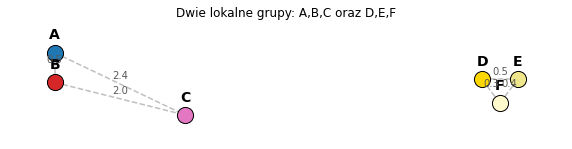

### Ręczna macierz odległości

,A,B,C,D,E,F
A,0.0,0.5,2.4,10.0,9.5,9.8
B,0.5,0.0,2.0,9.8,9.0,9.2
C,2.4,2.0,0.0,8.0,8.2,8.0
D,10.0,9.8,8.0,0.0,0.5,0.3
E,9.5,9.0,8.2,0.5,0.0,0.4
F,9.8,9.2,8.0,0.3,0.4,0.0


In [2]:
fig, ax = plt.subplots(figsize=(10, 3.8))
plot_points(ax, title="Dwie lokalne grupy: A,B,C oraz D,E,F")
plt.show()

display(Markdown("### Ręczna macierz odległości"))
display(df_matrix(D))


## 2. UMAP: wybieramy tylko lokalnych sąsiadów

W tym przykładzie dla każdego punktu bierzemy tylko **dwóch najbliższych sąsiadów**.

To oznacza, że dla punktu $A$ sąsiadami będą:

$$
B \quad \text{i} \quad C,
$$

ale nie będą nimi:

$$
D,E,F.
$$

Dlatego w kierunkowym grafie UMAP dostaniemy:

$$
 p(D\mid A)=p(E\mid A)=p(F\mid A)=0.
$$

To nie znaczy, że te punkty „nie istnieją”. To znaczy tylko, że **UMAP buduje rzadki graf lokalny**, a nie pełny graf wszystkich par.


,punkt,najbliższy 1,najbliższy 2,odległość 1,odległość 2
0,A,B,C,0.5,2.4
1,B,A,C,0.5,2.0
2,C,B,A,2.0,2.4
3,D,F,E,0.3,0.5
4,E,F,D,0.4,0.5
5,F,D,E,0.3,0.4


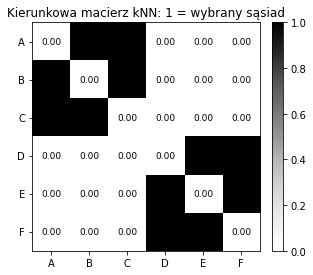

In [3]:
neigh = directed_knn_indices(D, n_neighbors=2)
rows = []
for i, ns in enumerate(neigh):
    rows.append({"punkt": labels[i], "najbliższy 1": labels[ns[0]], "najbliższy 2": labels[ns[1]],
                 "odległość 1": D[i, ns[0]], "odległość 2": D[i, ns[1]]})
display(pd.DataFrame(rows))

# Macierz 0/1: czy j jest jednym z dwóch najbliższych sąsiadów i?
A_knn = np.zeros_like(D)
for i, ns in enumerate(neigh):
    for j in ns:
        A_knn[i,j] = 1
fig, ax = plt.subplots(figsize=(5.2,4.2))
plot_heatmap(A_knn, "Kierunkowa macierz kNN: 1 = wybrany sąsiad", ax=ax, cmap='Greys')
plt.show()


## 3. UMAP: wzór na kierunkowy similarity score

Dla punktu $i$ UMAP używa lokalnej skali $\sigma_i$ i przesunięcia $\rho_i$:

$$
\rho_i = \min_{j\in kNN(i)} d(x_i,x_j).
$$

Następnie dla sąsiada $j$:

$$
 p(j\mid i)=\exp\left(-\frac{\max(0,d(x_i,x_j)-\rho_i)}{\sigma_i}\right).
$$

Najbliższy sąsiad ma zwykle score równy $1$, bo wtedy:

$$
 d(x_i,x_j)-\rho_i=0.
$$

W mini-przykładzie kalibrujemy $\sigma_i$ tak, aby lokalna suma wag była bliska:

$$
\sum_{j\in kNN(i)} p(j\mid i) \approx \log_2(3).
$$

Ta wartość odpowiada przykładom typu $\sigma_A\approx 3.5$ i $\sigma_B\approx 2.8$.


,punkt,rho_i,sigma_i,suma wag
0,A,0.5,3.5434,1.585
1,B,0.5,2.7974,1.585
2,C,2.0,0.7460,1.585
3,D,0.3,0.3730,1.585
4,E,0.4,0.1865,1.585
5,F,0.3,0.1865,1.585


### Kierunkowa macierz similarity scores: $p(j\mid i)$

,A,B,C,D,E,F
A,0.000,1.0,0.585,0.000,0.000,0.0
B,1.000,0.0,0.585,0.000,0.000,0.0
C,0.585,1.0,0.000,0.000,0.000,0.0
D,0.000,0.0,0.000,0.000,0.585,1.0
E,0.000,0.0,0.000,0.585,0.000,1.0
F,0.000,0.0,0.000,1.000,0.585,0.0


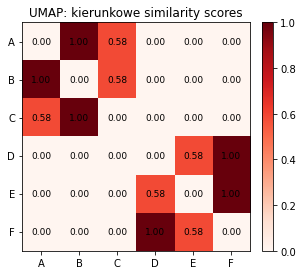

In [4]:
Pdir, sigmas, rhos, neigh = umap_directed_scores(D, n_neighbors=2, target=np.log2(3))

info = []
for i, lab in enumerate(labels):
    info.append({"punkt": lab, "rho_i": rhos[i], "sigma_i": sigmas[i], "suma wag": Pdir[i].sum()})
display(pd.DataFrame(info).round(4))

display(Markdown("### Kierunkowa macierz similarity scores: $p(j\\mid i)$"))
display(df_matrix(Pdir))

fig, ax = plt.subplots(figsize=(5.2,4.2))
plot_heatmap(Pdir, "UMAP: kierunkowe similarity scores", ax=ax, cmap='Reds')
plt.show()


## 4. Ręczne liczenie dla punktu $A$

Dla punktu $A$ mamy:

$$
 d(A,B)=0.5,\qquad d(A,C)=2.4.
$$

Najbliższy sąsiad to $B$, więc:

$$
\rho_A = 0.5.
$$

Dla $B$:

$$
 p(B\mid A)=\exp\left(-\frac{\max(0,0.5-0.5)}{\sigma_A}\right)=\exp(0)=1.
$$

Dla $C$, jeśli $\sigma_A=3.5$:

$$
 p(C\mid A)=\exp\left(-\frac{2.4-0.5}{3.5}\right)
=\exp(-0.5429)\approx 0.58\approx 0.6.
$$

Dla $D,E,F$:

$$
 p(D\mid A)=p(E\mid A)=p(F\mid A)=0,
$$

bo nie są wśród najbliższych sąsiadów punktu $A$.


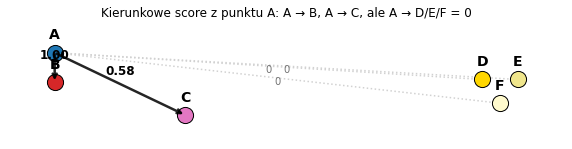

In [5]:
def plot_A_scores():
    fig, ax = plt.subplots(figsize=(10, 3.8))
    plot_points(ax, title="Kierunkowe score z punktu A: A → B, A → C, ale A → D/E/F = 0", annotate_distances=False)
    i = labels.index("A")
    xi, yi = X_plot[i]
    # Arrows for all other points
    for j, lab in enumerate(labels):
        if j == i:
            continue
        xj, yj = X_plot[j]
        score = Pdir[i,j]
        if score > 0:
            ax.annotate("", xy=(xj,yj), xytext=(xi,yi), arrowprops=dict(arrowstyle="->", lw=2.5, alpha=0.85))
            ax.text((xi+xj)/2, (yi+yj)/2+0.15, f"{score:.2f}", ha='center', fontsize=12, fontweight='bold')
        else:
            ax.plot([xi,xj],[yi,yj], linestyle=':', color='0.82', zorder=0)
            ax.text((xi+xj)/2, (yi+yj)/2-0.12, "0", ha='center', fontsize=10, color='0.45')
    plt.show()
plot_A_scores()


## 5. Jak zmiana $\sigma_A$ zmienia score $p(C\mid A)$?

Trzymamy:

$$
\rho_A=0.5,\qquad d(A,C)=2.4.
$$

Zmieniamy tylko $\sigma_A$:

$$
 p(C\mid A)=\exp\left(-\frac{2.4-0.5}{\sigma_A}\right).
$$

Większe $\sigma_A$ oznacza wolniejszy spadek podobieństwa wraz z odległością.


,sigma_A,p(B|A),p(C|A),suma
0,1.0,1.0,0.1496,1.1496
1,2.0,1.0,0.3867,1.3867
2,3.5,1.0,0.5811,1.5811


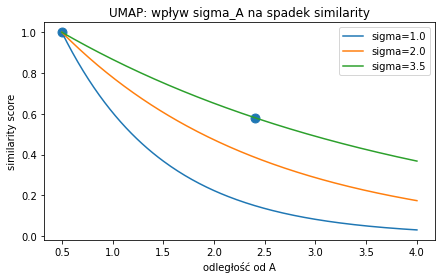

In [6]:
sigma_values = [1.0, 2.0, 3.5]
rows = []
for s in sigma_values:
    score = np.exp(-(2.4 - 0.5)/s)
    rows.append({"sigma_A": s, "p(B|A)": 1.0, "p(C|A)": score, "suma": 1.0 + score})
display(pd.DataFrame(rows).round(4))

x = np.linspace(0.5, 4.0, 200)
fig, ax = plt.subplots(figsize=(7,4))
for s in sigma_values:
    y = np.exp(-np.maximum(0, x-0.5)/s)
    ax.plot(x, y, label=f"sigma={s}")
ax.scatter([0.5,2.4], [1, np.exp(-(2.4-0.5)/3.5)], s=80)
ax.set_xlabel("odległość od A")
ax.set_ylabel("similarity score")
ax.set_title("UMAP: wpływ sigma_A na spadek similarity")
ax.legend()
plt.show()


## 6. Symetryzacja: fuzzy union

Po poprzednim kroku mamy score kierunkowe:

$$
 p(j\mid i) \neq p(i\mid j).
$$

UMAP chce mieć jedną wagę krawędzi między $i$ i $j$. Używa fuzzy union:

$$
 P_{ij}=p(j\mid i)+p(i\mid j)-p(j\mid i)p(i\mid j).
$$

To jest analogiczne do prawdopodobieństwa sumy zdarzeń:

$$
P(A\cup B)=P(A)+P(B)-P(A)P(B).
$$

Przykład:

$$
0.6+1.0-0.6\cdot 1.0=1.0.
$$

A jeśli oba kierunki mają około $0.6$:

$$
0.6+0.6-0.6\cdot 0.6=0.84\approx 0.8.
$$


### Symetryczna macierz fuzzy similarity $P_{ij}$

,A,B,C,D,E,F
A,0.000,1.0,0.828,0.000,0.000,0.0
B,1.000,0.0,1.000,0.000,0.000,0.0
C,0.828,1.0,0.000,0.000,0.000,0.0
D,0.000,0.0,0.000,0.000,0.828,1.0
E,0.000,0.0,0.000,0.828,0.000,1.0
F,0.000,0.0,0.000,1.000,1.000,0.0


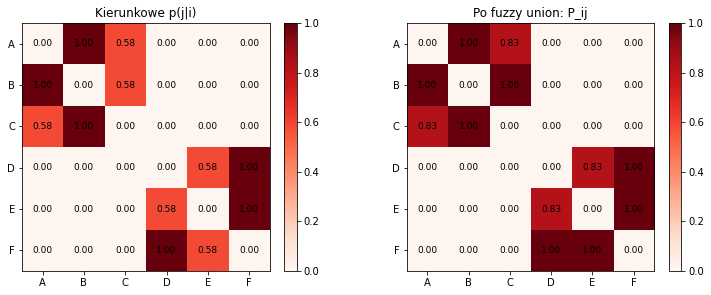

,para,p(j|i),p(i|j),fuzzy union
0,B-C,0.585,1.000,1.0000
1,A-C,0.585,0.585,0.8277
2,A-B,1.000,1.000,1.0000
3,D-E,0.585,0.585,0.8277


In [7]:
Psym = fuzzy_union(Pdir)

display(Markdown("### Symetryczna macierz fuzzy similarity $P_{ij}$"))
display(df_matrix(Psym))

fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
plot_heatmap(Pdir, "Kierunkowe p(j|i)", ax=axes[0], cmap='Reds')
plot_heatmap(Psym, "Po fuzzy union: P_ij", ax=axes[1], cmap='Reds')
plt.tight_layout()
plt.show()

examples = []
for pair in [("B","C"),("A","C"),("A","B"),("D","E")]:
    i, j = labels.index(pair[0]), labels.index(pair[1])
    s1 = Pdir[i,j]
    s2 = Pdir[j,i]
    sym = Psym[i,j]
    examples.append({"para": f"{pair[0]}-{pair[1]}", "p(j|i)": s1, "p(i|j)": s2, "fuzzy union": sym})
display(pd.DataFrame(examples).round(4))


## 7. t-SNE: podobny cel, inne similarity score

W t-SNE także zamieniamy odległości na podobieństwa, ale robimy to inaczej.

Dla punktu $i$ liczymy nieznormalizowane score Gaussowskie:

$$
 s(j\mid i)=\exp\left(-\frac{d(x_i,x_j)^2}{2\sigma_i^2}\right).
$$

Potem normalizujemy:

$$
 p(j\mid i)=\frac{s(j\mid i)}{\sum_{k\neq i}s(k\mid i)}.
$$

Różnica intuicyjna:

- **UMAP**: buduje rzadki fuzzy graf kNN.
- **t-SNE**: buduje rozkład prawdopodobieństwa podobieństw, a $\sigma_i$ dobiera przez perplexity.


,sigma_A,p(B|A),p(C|A),p(D|A),p(E|A),p(F|A)
0,0.5,1.0000,0.0000,0.0000,0.0000,0.0000
1,1.0,0.9402,0.0598,0.0000,0.0000,0.0000
2,2.0,0.6657,0.3343,0.0000,0.0000,0.0000
3,3.5,0.5373,0.4291,0.0092,0.0136,0.0108


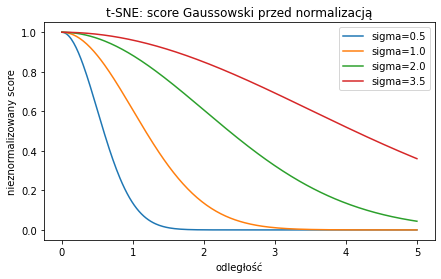

In [8]:
def tsne_conditional_probs_from_dist_row(drow, sigma):
    s = np.exp(-(drow**2)/(2*sigma**2))
    s = s.copy()
    # punkt sam do siebie pomijamy
    # zakładamy, że zero na przekątnej oznacza self
    s[drow == 0] = 0
    return s / s.sum()

sigmas_demo = [0.5, 1.0, 2.0, 3.5]
rows = []
row_A = D[labels.index("A")]
for s in sigmas_demo:
    p = tsne_conditional_probs_from_dist_row(row_A, sigma=s)
    rows.append({"sigma_A": s, **{f"p({lab}|A)": p[j] for j, lab in enumerate(labels) if lab != "A"}})
display(pd.DataFrame(rows).round(4))

# Wizualizacja Gaussa dla różnych sigma
x = np.linspace(0, 5, 300)
fig, ax = plt.subplots(figsize=(7,4))
for s in sigmas_demo:
    y = np.exp(-(x**2)/(2*s**2))
    ax.plot(x, y, label=f"sigma={s}")
ax.set_xlabel("odległość")
ax.set_ylabel("nieznormalizowany score")
ax.set_title("t-SNE: score Gaussowski przed normalizacją")
ax.legend()
plt.show()


## 8. Najważniejsze porównanie na tym etapie

| Etap | UMAP | t-SNE |
|---|---|---|
| Wysoki wymiar | rzadki graf kNN | rozkład prawdopodobieństwa dla sąsiadów |
| Lokalna skala | $\sigma_i$ tak, aby suma wag była bliska $\log_2(k)$ | $\sigma_i$ tak, aby perplexity miało zadaną wartość |
| Score kierunkowy | $\exp(-(d-\rho_i)/\sigma_i)$ | $\exp(-d^2/(2\sigma_i^2))$ i normalizacja |
| Symetryzacja | fuzzy union: $a+b-ab$ | średnia: $P_{ij}=(p_{j|i}+p_{i|j})/(2n)$ |

Na razie kończymy na similarity scores. Pełna optymalizacja mapy jest w kolejnych notebookach.
